Chuyển về profile demo(powershell): `$env:DATA_PROFILE = "eval"`
Khởi động back-end demo: `uvicorn src.backend.main:app --port 8001`

In [25]:
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

for pkg in ["requests", "tabulate", "matplotlib", "numpy"]:
    try:
        __import__(pkg)
    except ImportError:
        print(f"Đang cài {pkg}...")
        install(pkg)

In [ ]:
import os
import json
import time
import requests
import matplotlib.pyplot as plt
from tabulate import tabulate
from typing import Optional

K = 10
BASE_URL = "http://127.0.0.1:8001"
JSON_PATH = JSON_PATH = next(
    (p for p in (
        "data/eval/raw/wiki_crawler_dataset.json",
        "../data/eval/raw/wiki_crawler_dataset.json",
        "../../data/eval/raw/wiki_crawler_dataset.json",
    ) if os.path.exists(p)),
    "data/eval/raw/wiki_crawler_dataset.json"
)
OUTPUT_FILE = "eval_results.json"
VERBOSE = True

SyntaxError: '(' was never closed (1816631099.py, line 11)

In [27]:
GROUND_TRUTH = [
    {
        "query_id": "Q01",
        "query": "deep learning neural network architectures",
        "relevant_urls": [
            "https://en.wikipedia.org/wiki/Deep_learning",
            "https://en.wikipedia.org/wiki/Long_short-term_memory",
            "https://en.wikipedia.org/wiki/Neural_network_(biology)",
            "https://en.wikipedia.org/wiki/Residual_neural_network",
        ],
    },
    {
        "query_id": "Q02",
        "query": "Geoffrey Hinton deep learning researcher",
        "relevant_urls": [
            "https://en.wikipedia.org/wiki/Geoffrey_Hinton",
        ],
    },
    {
        "query_id": "Q03",
        "query": "gradient descent and optimization software",
        "relevant_urls": [
            "https://en.wikipedia.org/wiki/Comparison_of_optimization_software",
            "https://en.wikipedia.org/wiki/Gekko_(optimization_software)",
            "https://en.wikipedia.org/wiki/Gradient-enhanced_kriging",
            "https://en.wikipedia.org/wiki/Gradient_descent",
            "https://en.wikipedia.org/wiki/Gurobi_Optimizer",
            "https://en.wikipedia.org/wiki/HiGHS_optimization_solver",
            "https://en.wikipedia.org/wiki/List_of_optimization_software",
            "https://en.wikipedia.org/wiki/MINOS_(optimization_software)",
        ],
    },
    {
        "query_id": "Q04",
        "query": "unemployment types and causes",
        "relevant_urls": [
            "https://en.wikipedia.org/wiki/Frictional_unemployment",
            "https://en.wikipedia.org/wiki/Graduate_unemployment",
            "https://en.wikipedia.org/wiki/Involuntary_unemployment",
            "https://en.wikipedia.org/wiki/Job_creation_program",
            "https://en.wikipedia.org/wiki/Structural_unemployment",
            "https://en.wikipedia.org/wiki/Types_of_unemployment",
            "https://en.wikipedia.org/wiki/Unemployed",
            "https://en.wikipedia.org/wiki/Unemployment",
            "https://en.wikipedia.org/wiki/Youth_unemployment",
        ],
    },
    {
        "query_id": "Q05",
        "query": "unemployment benefits and job guarantee programs",
        "relevant_urls": [
            "https://en.wikipedia.org/wiki/Employer_of_last_resort",
            "https://en.wikipedia.org/wiki/Guaranteed_minimum_income",
            "https://en.wikipedia.org/wiki/Job_creation_index",
            "https://en.wikipedia.org/wiki/Job_guarantee",
            "https://en.wikipedia.org/wiki/Unemployment_benefits",
            "https://en.wikipedia.org/wiki/Unemployment_extension",
            "https://en.wikipedia.org/wiki/Unemployment_insurance",
            "https://en.wikipedia.org/wiki/Workfare",
            "https://en.wikipedia.org/wiki/Works_Progress_Administration",
        ],
    },
    {
        "query_id": "Q06",
        "query": "minimum wage and living wage laws",
        "relevant_urls": [
            "https://en.wikipedia.org/wiki/List_of_European_countries_by_minimum_wage",
            "https://en.wikipedia.org/wiki/Living_wage",
            "https://en.wikipedia.org/wiki/Maximum_wage",
            "https://en.wikipedia.org/wiki/Minimum_Wage_Ordinance",
            "https://en.wikipedia.org/wiki/Minimum_wage",
            "https://en.wikipedia.org/wiki/Minimum_wage_in_Canada",
            "https://en.wikipedia.org/wiki/Minimum_wage_in_the_United_States",
            "https://en.wikipedia.org/wiki/National_Minimum_Wage_Act_1998",
        ],
    },
    {
        "query_id": "Q07",
        "query": "wage theft compression and labour wages",
        "relevant_urls": [
            "https://en.wikipedia.org/wiki/Decoupling_of_wages_from_productivity",
            "https://en.wikipedia.org/wiki/List_of_countries_by_average_wage",
            "https://en.wikipedia.org/wiki/Progressive_wage",
            "https://en.wikipedia.org/wiki/Truck_wages",
            "https://en.wikipedia.org/wiki/Union_wage_premium",
            "https://en.wikipedia.org/wiki/Wage",
            "https://en.wikipedia.org/wiki/Wage_compression",
            "https://en.wikipedia.org/wiki/Wage_curve",
            "https://en.wikipedia.org/wiki/Wage_labor",
            "https://en.wikipedia.org/wiki/Wage_labour",
            "https://en.wikipedia.org/wiki/Wage_slavery",
            "https://en.wikipedia.org/wiki/Wage_theft",
        ],
    },
    {
        "query_id": "Q08",
        "query": "whistleblower protection and reporting misconduct",
        "relevant_urls": [
            "https://en.wikipedia.org/wiki/David_McBride_(whistleblower)",
            "https://en.wikipedia.org/wiki/List_of_EPA_whistleblowers",
            "https://en.wikipedia.org/wiki/List_of_nuclear_whistleblowers",
            "https://en.wikipedia.org/wiki/List_of_whistleblowers",
            "https://en.wikipedia.org/wiki/National_Whistleblower_Appreciation_Day",
            "https://en.wikipedia.org/wiki/National_Whistleblower_Center",
            "https://en.wikipedia.org/wiki/Nuclear_whistleblowers",
            "https://en.wikipedia.org/wiki/SEC_Office_of_the_Whistleblower",
            "https://en.wikipedia.org/wiki/Whistle-blowing_policy_in_Nigeria",
            "https://en.wikipedia.org/wiki/Whistleblower",
            "https://en.wikipedia.org/wiki/Whistleblower_Office",
            "https://en.wikipedia.org/wiki/Whistleblower_protection_in_Australia",
            "https://en.wikipedia.org/wiki/Whistleblower_protection_in_India",
            "https://en.wikipedia.org/wiki/Whistleblower_protection_in_the_United_States",
        ],
    },
    {
        "query_id": "Q09",
        "query": "anti-corruption commissions and bureaus",
        "relevant_urls": [
            "https://en.wikipedia.org/wiki/2011_Indian_anti-corruption_movement",
            "https://en.wikipedia.org/wiki/2012_Indian_anti-corruption_movement",
            "https://en.wikipedia.org/wiki/Anti-Corruption_Commission_(Bangladesh)",
            "https://en.wikipedia.org/wiki/Anti-Corruption_Commission_of_Myanmar",
            "https://en.wikipedia.org/wiki/Anti-Corruption_General_Directorate",
            "https://en.wikipedia.org/wiki/Anti-Corruption_Prosecutor%27s_Office",
            "https://en.wikipedia.org/wiki/Anti-Corruption_and_Civil_Rights_Commission",
            "https://en.wikipedia.org/wiki/Anti-corruption",
            "https://en.wikipedia.org/wiki/Anti-corruption_and_Economic_Malpractice_Observatory",
            "https://en.wikipedia.org/wiki/Central_Steering_Committee_on_Anti-corruption",
            "https://en.wikipedia.org/wiki/Commission_Against_Corruption_(Macau)",
            "https://en.wikipedia.org/wiki/Corruption_Eradication_Commission",
            "https://en.wikipedia.org/wiki/Corruption_Prevention_and_Combating_Bureau",
            "https://en.wikipedia.org/wiki/Fiji_Independent_Commission_Against_Corruption",
            "https://en.wikipedia.org/wiki/Group_of_States_Against_Corruption",
            "https://en.wikipedia.org/wiki/Independent_Commission_Against_Corruption_(Hong_Kong)",
            "https://en.wikipedia.org/wiki/Inter-American_Convention_Against_Corruption",
            "https://en.wikipedia.org/wiki/International_Anti-Corruption_Academy",
            "https://en.wikipedia.org/wiki/International_Association_of_Anti-Corruption_Authorities",
            "https://en.wikipedia.org/wiki/Law_on_transparency,_the_fight_against_corruption_and_the_modernization_of_economic_life",
            "https://en.wikipedia.org/wiki/Malaysian_Anti-Corruption_Commission",
            "https://en.wikipedia.org/wiki/National_Anti-Corruption_Bureau_of_Ukraine",
            "https://en.wikipedia.org/wiki/National_Anti-Corruption_Observatory",
            "https://en.wikipedia.org/wiki/National_Anticorruption_Directorate",
            "https://en.wikipedia.org/wiki/Oficina_Anticorrupci%C3%B3n",
            "https://en.wikipedia.org/wiki/Russian_anti-corruption_campaign",
            "https://en.wikipedia.org/wiki/Sierra_Leone_Anti-corruption_Commission",
            "https://en.wikipedia.org/wiki/Specialized_Anti-Corruption_Prosecutor%27s_Office",
            "https://en.wikipedia.org/wiki/United_Nations_Convention_against_Corruption",
        ],
    },
    {
        "query_id": "Q10",
        "query": "bribery embezzlement and financial crime corruption",
        "relevant_urls": [
            "https://en.wikipedia.org/wiki/Bribery",
            "https://en.wikipedia.org/wiki/Commercial_bribery",
            "https://en.wikipedia.org/wiki/Embezzlement",
            "https://en.wikipedia.org/wiki/Extortion",
            "https://en.wikipedia.org/wiki/Foreign_Extortion_Prevention_Act",
            "https://en.wikipedia.org/wiki/Graft_(politics)",
            "https://en.wikipedia.org/wiki/Kickback_(finance)",
            "https://en.wikipedia.org/wiki/Kleptocracy",
            "https://en.wikipedia.org/wiki/Money_laundering",
            "https://en.wikipedia.org/wiki/OECD_Anti-Bribery_Convention",
            "https://en.wikipedia.org/wiki/Slush_fund",
        ],
    },
    {
        "query_id": "Q11",
        "query": "school bullying and anti-bullying campaigns",
        "relevant_urls": [
            "https://en.wikipedia.org/wiki/Anti-Bullying_Week",
            "https://en.wikipedia.org/wiki/Anti-bullying_legislation",
            "https://en.wikipedia.org/wiki/Bullying_UK",
            "https://en.wikipedia.org/wiki/Bullying_and_emotional_intelligence",
            "https://en.wikipedia.org/wiki/International_Stand_Up_to_Bullying_Day",
            "https://en.wikipedia.org/wiki/School_bullying",
        ],
    },
    {
        "query_id": "Q12",
        "query": "workplace bullying in professions",
        "relevant_urls": [
            "https://en.wikipedia.org/wiki/Bullying_in_information_technology",
            "https://en.wikipedia.org/wiki/Bullying_in_medicine",
            "https://en.wikipedia.org/wiki/Bullying_in_nursing",
            "https://en.wikipedia.org/wiki/Bullying_in_teaching",
            "https://en.wikipedia.org/wiki/Bullying_in_the_legal_profession",
            "https://en.wikipedia.org/wiki/Bullying_in_the_military",
            "https://en.wikipedia.org/wiki/Bullying_of_students_in_higher_education",
            "https://en.wikipedia.org/wiki/Legal_aspects_of_workplace_bullying",
            "https://en.wikipedia.org/wiki/Sexual_bullying",
            "https://en.wikipedia.org/wiki/Workplace_bullying_in_academia",
        ],
    },
    {
        "query_id": "Q13",
        "query": "teen suicides attributed to bullying",
        "relevant_urls": [
            "https://en.wikipedia.org/wiki/Bullying_and_suicide",
            "https://en.wikipedia.org/wiki/List_of_suicides_that_have_been_attributed_to_bullying",
            "https://en.wikipedia.org/wiki/Suicide_of_Dawn-Marie_Wesley",
            "https://en.wikipedia.org/wiki/Suicide_of_Hamed_Nastoh",
            "https://en.wikipedia.org/wiki/Suicide_of_Jadin_Bell",
            "https://en.wikipedia.org/wiki/Suicide_of_Jamey_Rodemeyer",
            "https://en.wikipedia.org/wiki/Suicide_of_Kelly_Yeomans",
            "https://en.wikipedia.org/wiki/Suicide_of_Kenneth_Weishuhn",
            "https://en.wikipedia.org/wiki/Suicide_of_Lia_Smith",
            "https://en.wikipedia.org/wiki/Suicide_of_Megan_Meier",
            "https://en.wikipedia.org/wiki/Suicide_of_Nicola_Ann_Raphael",
            "https://en.wikipedia.org/wiki/Suicide_of_Phoebe_Prince",
            "https://en.wikipedia.org/wiki/Suicide_of_Rebecca_Sedwick",
            "https://en.wikipedia.org/wiki/Suicide_of_Ryan_Halligan",
            "https://en.wikipedia.org/wiki/Suicide_of_Sladjana_Vidovic",
            "https://en.wikipedia.org/wiki/Suicide_of_Tyler_Clementi",
            "https://en.wikipedia.org/wiki/Suicide_of_Tyrone_Unsworth",
            "https://en.wikipedia.org/wiki/Suicide_of_William_Arthur_Gibbs",
        ],
    },
    {
        "query_id": "Q14",
        "query": "electoral fraud voter suppression gerrymandering",
        "relevant_urls": [
            "https://en.wikipedia.org/wiki/Ballot_stuffing",
            "https://en.wikipedia.org/wiki/Election_security",
            "https://en.wikipedia.org/wiki/Electoral_fraud",
            "https://en.wikipedia.org/wiki/Gerrymandering",
            "https://en.wikipedia.org/wiki/Unfair_election",
            "https://en.wikipedia.org/wiki/Vote_pairing",
            "https://en.wikipedia.org/wiki/Vote_suppression",
        ],
    },
    {
        "query_id": "Q15",
        "query": "reduced working week and working hours movements",
        "relevant_urls": [
            "https://en.wikipedia.org/wiki/35-hour_workweek",
            "https://en.wikipedia.org/wiki/40-hour_week",
            "https://en.wikipedia.org/wiki/996_working_hour_system",
            "https://en.wikipedia.org/wiki/Eight-hour_day",
            "https://en.wikipedia.org/wiki/Four-day_week",
            "https://en.wikipedia.org/wiki/Four-day_workweek",
            "https://en.wikipedia.org/wiki/Six-hour_day",
            "https://en.wikipedia.org/wiki/Working_Time_Directive_2003",
            "https://en.wikipedia.org/wiki/Working_time",
            "https://en.wikipedia.org/wiki/Workweek",
            "https://en.wikipedia.org/wiki/Workweek_and_weekend",
        ],
    },
    {
        "query_id": "Q16",
        "query": "worker classification by collar color",
        "relevant_urls": [
            "https://en.wikipedia.org/wiki/Blue-collar_worker",
            "https://en.wikipedia.org/wiki/Designation_of_workers_by_collar_color",
            "https://en.wikipedia.org/wiki/Green-collar_worker",
            "https://en.wikipedia.org/wiki/Grey-collar",
            "https://en.wikipedia.org/wiki/New-collar_worker",
            "https://en.wikipedia.org/wiki/Pink-collar_worker",
        ],
    },
    {
        "query_id": "Q17",
        "query": "pension retirement planning and benefits",
        "relevant_urls": [
            "https://en.wikipedia.org/wiki/Golden_handshake",
            "https://en.wikipedia.org/wiki/Golden_parachute",
            "https://en.wikipedia.org/wiki/Mandatory_retirement",
            "https://en.wikipedia.org/wiki/Pension",
            "https://en.wikipedia.org/wiki/Pension_systems_by_country",
            "https://en.wikipedia.org/wiki/Pensioner",
            "https://en.wikipedia.org/wiki/Retired",
            "https://en.wikipedia.org/wiki/Retirement",
            "https://en.wikipedia.org/wiki/Retirement_planning",
            "https://en.wikipedia.org/wiki/Retirement_spend-down",
            "https://en.wikipedia.org/wiki/Superannuation_Act_2010",
        ],
    },
    {
        "query_id": "Q18",
        "query": "job hunting resume cover letter and interview",
        "relevant_urls": [
            "https://en.wikipedia.org/wiki/Application_for_employment",
            "https://en.wikipedia.org/wiki/Cover_letter",
            "https://en.wikipedia.org/wiki/Curriculum_vitae",
            "https://en.wikipedia.org/wiki/Job_fair",
            "https://en.wikipedia.org/wiki/Job_hunting",
            "https://en.wikipedia.org/wiki/Job_interview",
            "https://en.wikipedia.org/wiki/Letter_of_recommendation",
            "https://en.wikipedia.org/wiki/R%C3%A9sum%C3%A9",
            "https://en.wikipedia.org/wiki/Resume",
        ],
    },
    {
        "query_id": "Q19",
        "query": "nepotism cronyism and favoritism",
        "relevant_urls": [
            "https://en.wikipedia.org/wiki/Clientelism",
            "https://en.wikipedia.org/wiki/Crony_capitalism",
            "https://en.wikipedia.org/wiki/Cronyism",
            "https://en.wikipedia.org/wiki/Nepotism",
        ],
    },
    {
        "query_id": "Q20",
        "query": "leave of absence sick and parental leave",
        "relevant_urls": [
            "https://en.wikipedia.org/wiki/Annual_leave",
            "https://en.wikipedia.org/wiki/Bereavement_leave",
            "https://en.wikipedia.org/wiki/Compassionate_leave",
            "https://en.wikipedia.org/wiki/Leave_of_absence",
            "https://en.wikipedia.org/wiki/List_of_minimum_annual_leave_by_country",
            "https://en.wikipedia.org/wiki/Long_service_leave",
            "https://en.wikipedia.org/wiki/Marriage_leave",
            "https://en.wikipedia.org/wiki/Paid_time_off",
            "https://en.wikipedia.org/wiki/Parental_leave",
            "https://en.wikipedia.org/wiki/Sick_leave",
            "https://en.wikipedia.org/wiki/Sick_leave_in_the_United_States",
            "https://en.wikipedia.org/wiki/Stress_leave",
        ],
    },
]

In [28]:
def normalize_url(url: str) -> str:
    u = url.strip().rstrip("/").lower()
    return u.replace("-", "_")

def search_api(query: str, k: int, base_url: str) -> list:
    endpoint = f"{base_url}/search"
    response = requests.get(endpoint, params={"q": query, "k": k}, timeout=30)
    response.raise_for_status()
    return response.json().get("data", [])

def precision_at_k(retrieved: list, relevant: list, k: int) -> float:
    rel_set = {normalize_url(u) for u in relevant}
    hits = sum(1 for u in retrieved[:k] if normalize_url(u) in rel_set)
    return hits / k if k > 0 else 0.0

def average_precision(retrieved: list, relevant: list) -> float:
    rel_set = {normalize_url(u) for u in relevant}
    if not rel_set:
        return 0.0
    hits, total = 0, 0.0
    for i, url in enumerate(retrieved, start=1):
        if normalize_url(url) in rel_set:
            hits += 1
            total += hits / i
    return total / len(rel_set)

In [29]:
import os

coverage_ok = False
crawled_urls = set()

if os.path.exists(JSON_PATH):
    with open(JSON_PATH, "r", encoding="utf-8") as f:
        crawled_data = json.load(f)
    crawled_urls = {normalize_url(a.get("url", "")) for a in crawled_data}
    coverage_ok = True
    print(f"Raw dataset: {len(crawled_data)} bài viết\n")
else:
    print(f"Không tìm thấy {JSON_PATH} - bỏ qua bước kiểm tra coverage.")
    print("(Không ảnh hưởng đến việc đánh giá qua API, chỉ là cảnh báo)\n")

if coverage_ok:
    print(f"{'─'*70}")
    print("KIỂM TRA GROUND TRUTH URL CÓ TỒN TẠI TRONG DATASET KHÔNG")
    print(f"{'─'*70}")

    n_full, n_partial, n_zero = 0, 0, 0
    oracle_p_at_k = {}

    for gt in GROUND_TRUTH:
        qid, relevant = gt["query_id"], gt["relevant_urls"]
        found = [u for u in relevant if normalize_url(u) in crawled_urls]
        missing = [u for u in relevant if normalize_url(u) not in crawled_urls]

        oracle_p_at_k[qid] = min(len(found), K) / K

        if len(found) == len(relevant):
            n_full += 1
        elif len(found) > 0:
            n_partial += 1
        else:
            n_zero += 1

        print(f"[{qid}] {len(found)}/{len(relevant)} URL có trong dataset", end="")
        if missing:
            print(f"Thiếu: {[u.split('/wiki/')[-1] for u in missing]}")
        else:
            print()

    oracle_map = sum(
        (min(len(g["relevant_urls"]), len([u for u in g["relevant_urls"] if normalize_url(u) in crawled_urls]))
         / len(g["relevant_urls"])) if g["relevant_urls"] else 0
        for g in GROUND_TRUTH
    ) / len(GROUND_TRUTH)
    oracle_p10 = sum(oracle_p_at_k.values()) / len(oracle_p_at_k)

    print(f"\n{'─'*70}")
    print(f"Tổng kết coverage: Đủ={n_full} Thiếu 1 phần={n_partial} Thiếu hoàn toàn={n_zero}")
    print(f"-> P@{K} lý thuyết TỐI ĐA có thể đạt (nếu retrieval hoàn hảo) = {oracle_p10:.4f}")
    print(f"-> Đây là TRẦN của hệ thống — không thể vượt qua giá trị này dù thuật toán tốt đến đâu")
    print(f"{'─'*70}")

    if n_zero > 0:
        print(f"\nLƯU Ý: {n_zero} query có 0 URL relevant trong dataset.")
        print(f"-> AP của các query này sẽ luôn = 0, kéo MAP xuống bất kể thuật toán.")
        print(f"-> Cân nhắc: sửa lại ground truth, hoặc crawl bổ sung dữ liệu cho chủ đề đó.")

Không tìm thấy data/eval/raw/wiki_crawler_dataset.json - bỏ qua bước kiểm tra coverage.
(Không ảnh hưởng đến việc đánh giá qua API, chỉ là cảnh báo)



In [30]:
print("Đang kiểm tra kết nối backend...")
try:
    health = requests.get(f"{BASE_URL}/health", timeout=5).json()
    print(f"Backend OK – {health.get('collection_count', '?')} chunks trong vector DB")
    print(f"Full-text index: {health.get('full_text_index_size', '?')} bài viết")
    print(f"URL: {BASE_URL}")
except Exception as e:
    print(f"Không kết nối được backend tại {BASE_URL}")
    print(f"Lỗi: {e}")
    print("\n Hãy chạy lệnh sau trong terminal rồi thử lại:")
    print("uvicorn src.backend.main:app --port 8001")
    raise SystemExit("Backend không hoạt động")

Đang kiểm tra kết nối backend...
Backend OK – 92855 chunks trong vector DB
Full-text index: 5008 bài viết
URL: http://127.0.0.1:8001


In [31]:
print(f"\n{'═'*65}")
print(f"MODULE 5 – ĐÁNH GIÁ HỆ THỐNG TÌM KIẾM WIKISEARCH")
print(f"{'═'*65}")
print(f"Số truy vấn : {len(GROUND_TRUTH)}")
print(f"Đánh giá tại: K = {K}")
print(f"Backend URL : {BASE_URL}\n")

results = []
per_query_rows = []
total_p, total_ap = 0.0, 0.0
n_ok = 0

for gt in GROUND_TRUTH:
    qid, query, relevant = gt["query_id"], gt["query"], gt["relevant_urls"]

    if VERBOSE:
        print(f"[{qid}] {query[:62]}{'…' if len(query) > 62 else ''}")

    try:
        t0 = time.time()
        api_results = search_api(query, k=K, base_url=BASE_URL)
        elapsed_ms = round((time.time() - t0) * 1000, 1)
        retrieved = [r["url"] for r in api_results]

        p = precision_at_k(retrieved, relevant, K)
        ap = average_precision(retrieved, relevant)

        total_p += p
        total_ap += ap
        n_ok += 1

        per_query_rows.append({
            "QID": qid,
            "Query (rút gọn)": query[:42] + "…" if len(query) > 42 else query,
            f"P@{K}": f"{p:.4f}",
            "AP": f"{ap:.4f}",
            "|Relevant|": len(relevant),
            "ms": elapsed_ms,
        })

        results.append({
            "query_id": qid, "query": query,
            "retrieved_urls": retrieved,
            "relevant_urls": relevant,
            "metrics": {
                f"precision_at_{K}": round(p, 6),
                "average_precision": round(ap, 6),
                "response_time_ms": elapsed_ms,
            }
        })

    except Exception as e:
        print(f"Lỗi [{qid}]: {e}")
        results.append({"query_id": qid, "query": query, "error": str(e)})

print(f"\n Hoàn thành {n_ok}/{len(GROUND_TRUTH)} truy vấn")


═════════════════════════════════════════════════════════════════
MODULE 5 – ĐÁNH GIÁ HỆ THỐNG TÌM KIẾM WIKISEARCH
═════════════════════════════════════════════════════════════════
Số truy vấn : 20
Đánh giá tại: K = 10
Backend URL : http://127.0.0.1:8001

[Q01] deep learning neural network architectures
[Q02] Geoffrey Hinton deep learning researcher
[Q03] gradient descent and optimization software
[Q04] unemployment types and causes
[Q05] unemployment benefits and job guarantee programs
[Q06] minimum wage and living wage laws
[Q07] wage theft compression and labour wages
[Q08] whistleblower protection and reporting misconduct
[Q09] anti-corruption commissions and bureaus
[Q10] bribery embezzlement and financial crime corruption
[Q11] school bullying and anti-bullying campaigns
[Q12] workplace bullying in professions
[Q13] teen suicides attributed to bullying
[Q14] electoral fraud voter suppression gerrymandering
[Q15] reduced working week and working hours movements
[Q16] worker class

In [32]:
print(f"\n{'─'*80}")
print("KẾT QUẢ TỪNG TRUY VẤN (Precision@K & AP)")
print(f"{'─'*80}")

headers = list(per_query_rows[0].keys())
rows = [list(r.values()) for r in per_query_rows]
print(tabulate(rows, headers=headers, tablefmt="rounded_outline"))


────────────────────────────────────────────────────────────────────────────────
KẾT QUẢ TỪNG TRUY VẤN (Precision@K & AP)
────────────────────────────────────────────────────────────────────────────────
╭───────┬─────────────────────────────────────────────┬────────┬────────┬──────────────┬───────╮
│ QID   │ Query (rút gọn)                             │   P@10 │     AP │   |Relevant| │    ms │
├───────┼─────────────────────────────────────────────┼────────┼────────┼──────────────┼───────┤
│ Q01   │ deep learning neural network architectures  │    0.4 │ 1      │            4 │ 537.3 │
│ Q02   │ Geoffrey Hinton deep learning researcher    │    0.1 │ 1      │            1 │ 156.5 │
│ Q03   │ gradient descent and optimization software  │    0.7 │ 0.8294 │            8 │ 213.6 │
│ Q04   │ unemployment types and causes               │    0.8 │ 0.8889 │            9 │ 200.4 │
│ Q05   │ unemployment benefits and job guarantee pr… │    0.4 │ 0.4444 │            9 │ 212.7 │
│ Q06   │ minimum wa

In [33]:
map_score = total_ap / n_ok if n_ok else 0.0
mp_at_k = total_p / n_ok if n_ok else 0.0

def rate(val, good=0.5, mid=0.3):
    if val >= good: return " Tốt"
    if val >= mid: return " Trung bình"
    return " Cần cải thiện"

summary = [
    ["Số truy vấn đánh giá", f"{n_ok} / {len(GROUND_TRUTH)}", ""],
    [f"Precision@{K} (MP@{K})", f"{mp_at_k:.4f}", rate(mp_at_k, 0.4, 0.2)],
    ["MAP (Mean Average Precision)", f"{map_score:.4f}", rate(map_score, 0.5, 0.3)],
]

if coverage_ok:
    summary.append([f"Precision@{K} TỐI ĐA (Oracle)", f"{oracle_p10:.4f}", "giới hạn cứng của dataset"])
    gap = oracle_p10 - mp_at_k
    summary.append(["Khoảng cách tới giới hạn", f"{gap:.4f}", f"≈ {gap/oracle_p10*100:.0f}% dư địa cải thiện" if oracle_p10 > 0 else ""])

print(f"\n{'═'*70}")
print("TỔNG HỢP ĐÁNH GIÁ HỆ THỐNG (chỉ 2 chỉ số chính)")
print(f"{'═'*70}")
print(tabulate(summary, headers=["Chỉ số", "Giá trị", "Nhận xét"], tablefmt="rounded_outline"))

print()
print("Thang ngưỡng tham chiếu:")
print("≥ 0.5 -> Tốt | 0.3–0.5 -> Trung bình | < 0.3 -> Cần cải thiện")
print("(MAP ≥ 0.5 là đạt chuẩn tốt cho IR system; nguồn: TREC benchmark)")


══════════════════════════════════════════════════════════════════════
TỔNG HỢP ĐÁNH GIÁ HỆ THỐNG (chỉ 2 chỉ số chính)
══════════════════════════════════════════════════════════════════════
╭──────────────────────────────┬───────────┬────────────╮
│ Chỉ số                       │ Giá trị   │ Nhận xét   │
├──────────────────────────────┼───────────┼────────────┤
│ Số truy vấn đánh giá         │ 20 / 20   │            │
│ Precision@10 (MP@10)         │ 0.5750    │ Tốt        │
│ MAP (Mean Average Precision) │ 0.6441    │ Tốt        │
╰──────────────────────────────┴───────────┴────────────╯

Thang ngưỡng tham chiếu:
≥ 0.5 -> Tốt | 0.3–0.5 -> Trung bình | < 0.3 -> Cần cải thiện
(MAP ≥ 0.5 là đạt chuẩn tốt cho IR system; nguồn: TREC benchmark)


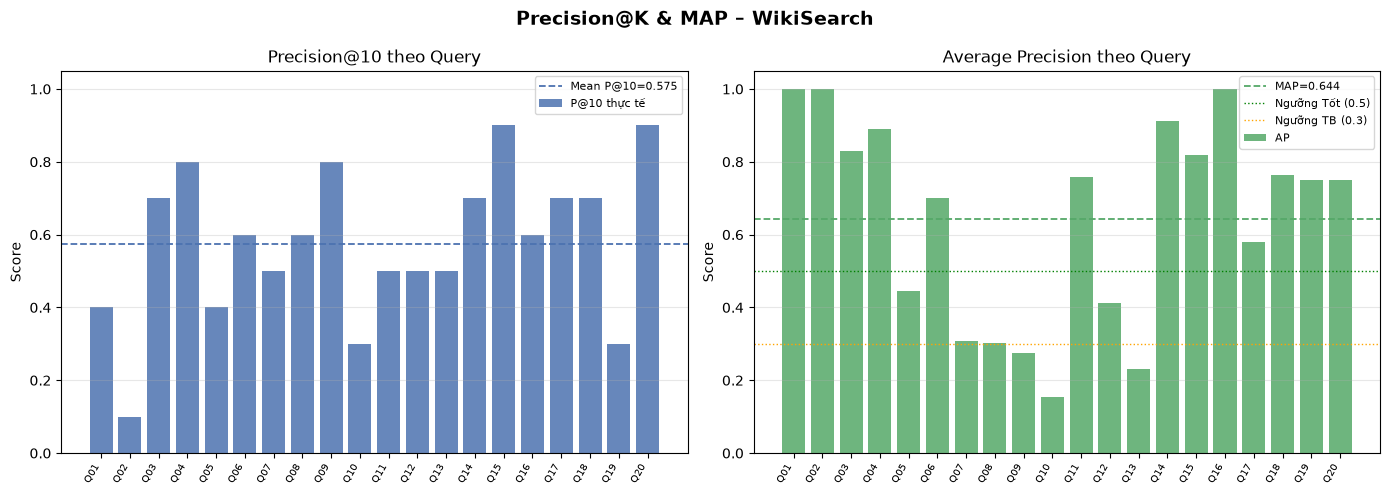

Đã lưu biểu đồ: eval_chart.png


In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Precision@K & MAP – WikiSearch", fontsize=14, fontweight="bold")

qids = [r["QID"] for r in per_query_rows]
p_vals = [float(r[f"P@{K}"]) for r in per_query_rows]
ap_vals = [float(r["AP"]) for r in per_query_rows]

ax = axes[0]
x = range(len(qids))
bars = ax.bar(x, p_vals, color="#4C72B0", alpha=0.85, label=f"P@{K} thực tế")
ax.axhline(mp_at_k, color="#4C72B0", linestyle="--", linewidth=1.3, label=f"Mean P@{K}={mp_at_k:.3f}")
if coverage_ok:
    oracle_vals = [oracle_p_at_k[q] for q in qids]
    ax.plot(x, oracle_vals, "o--", color="#C44E52", linewidth=1.2, markersize=5, label=f"P@{K} tối đa (Oracle)")
ax.set_xticks(list(x))
ax.set_xticklabels(qids, rotation=60, ha="right", fontsize=7)
ax.set_ylim(0, 1.05)
ax.set_title(f"Precision@{K} theo Query")
ax.set_ylabel("Score")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)

ax = axes[1]
ax.bar(x, ap_vals, color="#55A868", alpha=0.85, label="AP")
ax.axhline(map_score, color="#55A868", linestyle="--", linewidth=1.3, label=f"MAP={map_score:.3f}")
ax.axhline(0.5, color="green", linestyle=":", linewidth=1.0, label="Ngưỡng Tốt (0.5)")
ax.axhline(0.3, color="orange", linestyle=":", linewidth=1.0, label="Ngưỡng TB (0.3)")
ax.set_xticks(list(x))
ax.set_xticklabels(qids, rotation=60, ha="right", fontsize=7)
ax.set_ylim(0, 1.05)
ax.set_title("Average Precision theo Query")
ax.set_ylabel("Score")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("eval_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("Đã lưu biểu đồ: eval_chart.png")

In [35]:
valid_results = [r for r in results if "metrics" in r]
sorted_by_ap = sorted(valid_results, key=lambda r: r["metrics"]["average_precision"], reverse=True)
best3, worst3 = sorted_by_ap[:3], sorted_by_ap[-3:]

print("\n 3 query có AP cao nhất:")
for r in best3:
    print(f"[{r['query_id']}] AP={r['metrics']['average_precision']:.4f} | {r['query'][:65]}")

print("\n 3 query có AP thấp nhất:")
for r in worst3:
    print(f"[{r['query_id']}] AP={r['metrics']['average_precision']:.4f} | {r['query'][:65]}")



 3 query có AP cao nhất:
[Q01] AP=1.0000 | deep learning neural network architectures
[Q02] AP=1.0000 | Geoffrey Hinton deep learning researcher
[Q16] AP=1.0000 | worker classification by collar color

 3 query có AP thấp nhất:
[Q09] AP=0.2759 | anti-corruption commissions and bureaus
[Q13] AP=0.2315 | teen suicides attributed to bullying
[Q10] AP=0.1553 | bribery embezzlement and financial crime corruption


In [ ]:
output_data = {
    "evaluation_config": {
        "k": K,
        "backend_url": BASE_URL,
        "n_queries_total": len(GROUND_TRUTH),
        "n_queries_ok": n_ok,
    },
    "aggregate_metrics": {
        f"mean_precision_at_{K}": round(mp_at_k, 6),
        "MAP": round(map_score, 6),
    },
    "per_query_results": results,
}

if coverage_ok:
    output_data["oracle_metrics"] = {
        f"oracle_precision_at_{K}": round(oracle_p10, 6),
        "note": "Giới hạn lý thuyết tối đa dựa trên ground truth coverage trong dataset",
    }

if OUTPUT_FILE:
    with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
        json.dump(output_data, f, ensure_ascii=False, indent=2)
    print(f"Đã lưu kết quả chi tiết -> {OUTPUT_FILE}")

print()
print("═"*70)
print(f"ĐÁNH GIÁ HOÀN TẤT – Module 5 | SEG301 Final Project")
print(f"MAP = {map_score:.4f} | P@{K} = {mp_at_k:.4f}", end="")
if coverage_ok:
    print(f"| Oracle P@{K} = {oracle_p10:.4f}")
else:
    print()
print("═"*70)

Đã lưu kết quả chi tiết → eval_results.json

══════════════════════════════════════════════════════════════════════
ĐÁNH GIÁ HOÀN TẤT – Module 5 | SEG301 Final Project
MAP = 0.6441 | P@10 = 0.5750
══════════════════════════════════════════════════════════════════════
